# 5장 1강: 배깅과 랜덤포레스트

## 실습 목표
이번 실습에서는 **Ames Housing** 데이터를 이용하여 배깅과 랜덤포레스트의 핵심 원리를 확인합니다.

- 하나의 의사결정나무와 여러 나무를 모은 배깅의 차이를 확인합니다.
- 배깅에서 여러 회귀 모델의 예측을 평균내는 이유를 이해합니다.
- 랜덤포레스트의 부트스트랩과 피처 무작위 선택 개념을 확인합니다.
- OOB Score와 Feature Importance를 확인합니다.
- 여러 나무를 평균낼 때 분산이 줄어드는 이유를 설명합니다.

> 교안에 나온 범위만 사용합니다.

In [2]:
# 앙상블 : 여러 모델의 예측을 결합하여 하나의 최종 예측을 만드는 방법  
# 대표적인 앙상블 방법 : Tree형 모델(RandomForest), 배깅  

# 배깅 : 부트스트랩으로 만든 여러 표본에 각각 모델을 학습시키고 예측을 결합하는 앙상블 방법  
# 부트스트랩 : 표본을 여러개로 나누어서 결과물을 뽑고 결과물을 하나로 만드는 것  
# -> 고객 1,000명에서 여러 학습 표본을 만들고 각 표본으로 모델링을 학습하여, 예측 결과를 결합하는 것  

# RandomForest(RF, rf, Rf) : 여러 의사결정 나무를 학습하고 각 분할에서 특성 후보를 무작위로 고르는 방식을 활용, 예측을 결합하는 모델  
# -> 주택 가격을 예측할 때 나무 A는 면적을 중심으로, 나무 B는 위치를 중심으로 분할할 수 있다.  

# OOB : 여러 결정 트리를 만들 때 각 트리가 학습할 데이터를 중복을 허용해서 무작위로 뽑는데
# -> 어떤 데이터들은 여러번 뽑히고 어떤 데이터는 한 번도 안뽑힌다면
# -> 한 번도 안뽑힌 데이터를 OOB라고 부름

# OOB Score : 1을 예측할 때 1을 학습하지 않은 데이터만 모아서 학습하는데
# 예측 결과와 실제 정답을 비교하여 계산한 점수가 OOB Score
# -> 학습하지 않은 데이터를 얼마나 잘 예측할 수 있는가?

## 실습 환경 / 데이터
- Python, pandas, numpy, matplotlib, scikit-learn
- 데이터: `Ames_Housing.csv`
- 예측 대상: `SalePrice`

사용 특성:
`OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`, `1stFlrSF`,
`2ndFlrSF`, `FullBath`, `TotRmsAbvGrd`, `YearBuilt`, `YearRemodAdd`, `Fireplaces`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score

house = pd.read_csv("Ames_Housing.csv")

features = [
    "OverallQual","GrLivArea","GarageCars","GarageArea",
    "TotalBsmtSF","1stFlrSF","2ndFlrSF","FullBath",
    "TotRmsAbvGrd","YearBuilt","YearRemodAdd","Fireplaces"
]

X = house[features]
y = house["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
display(X.isna().sum().to_frame("missing"))

Train: (1168, 12)
Test: (292, 12)


,missing
OverallQual,0
GrLivArea,0
GarageCars,0
GarageArea,0
TotalBsmtSF,0
1stFlrSF,0
2ndFlrSF,0
FullBath,0
TotRmsAbvGrd,0
YearBuilt,0


# 필수 1. 하나의 나무와 Bagging 비교

## 문제 1. Decision Tree 하나를 학습하세요.
1. `DecisionTreeRegressor(random_state=42)` 사용
2. Train 학습
3. Train/Test 예측
4. Train R², Test R² 계산
5. 두 점수 차이 해석

In [ ]:
# TODO
# ===== 1·2. 모델 생성 및 학습 =====

tree = DecisionTreeRegressor(random_state=42)
# 깊이를 제한하지 않은 회귀 나무
# max_depth를 지정하지 않았기 때문에 무한하게 학습을 할수도 있겠다라고 판단할 수 있지만
# 더 나눌 수 없거나 기본 분할 조건을 만족하지 못하면 멈춘다. 

tree.fit(X_train, y_train)

# ===== 3. 예측 =====
train_pred = tree.predict(X_train)
test_pred  = tree.predict(X_test)

# ===== 4. R² 계산 =====
r2_train = r2_score(y_train, train_pred)
r2_test  = r2_score(y_test, test_pred)

print("[Decision Tree]")
print(f"  Train R² : {r2_train:.4f}")
print(f"  Test  R² : {r2_test:.4f}")
print(f"  차이     : {r2_train - r2_test:.4f}")
print(f"\n  나무 깊이 : {tree.get_depth()}  / 잎 개수 : {tree.get_n_leaves()}")


[Decision Tree]
  Train R² : 0.9999
  Test  R² : 0.7939
  차이     : 0.2060

  나무 깊이 : 26  / 잎 개수 : 1138


train이 1에 가깝다는 것의 의미  
-> 일반적으로 R²이 1에 가깝다는 것은 모델이 충분히 해당 데이터에 대한 설명력을 가지고 있다는 것이지만  
지나치게 성능이 높은 경우 과적합 위험을 의심하여 추가적인 검증이 필요하다.  

### Q1. Train R²는 매우 높은데 Test R²가 더 낮다면 무엇을 의미하나요?

**답변:**  
-> 하나의 나무가 학습 데이터 변화에 민감한 분산이 큰 모델임을 보여준다.  
Decision Tree의 한 그루는 불안정할 수 있다.

## 문제 2. Bagging을 적용하세요.
1. 기본 모델은 `DecisionTreeRegressor(random_state=42)`
2. `BaggingRegressor`
3. `n_estimators=50`
4. `random_state=42`
5. Test R² 계산
6. `max_features="sqrt`
7. Decision Tree 하나와 비교

In [5]:
# ===== 문제 2. Bagging =====
bagging = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),   # 1
    n_estimators=50,                                    # 3
    max_features=3,                                     # 6  (sqrt(12) ≈ 3)
    random_state=42,                                    # 4
)
bagging.fit(X_train, y_train)

r2_train_bag = r2_score(y_train, bagging.predict(X_train))
r2_test_bag  = r2_score(y_test,  bagging.predict(X_test))   # 5

print("[Bagging]")
print(f"  Train R² : {r2_train_bag:.4f}")
print(f"  Test  R² : {r2_test_bag:.4f}")
print(f"  차이     : {r2_train_bag - r2_test_bag:.4f}")

# ===== 7. Decision Tree 하나와 비교 =====
print("\n[비교]")
print(f"{'모델':20s} {'Train R²':>9} {'Test R²':>9} {'차이':>8}")
print(f"{'Decision Tree':20s} {r2_train:>9.4f} {r2_test:>9.4f} {r2_train-r2_test:>8.4f}")
print(f"{'Bagging(50)':20s} {r2_train_bag:>9.4f} {r2_test_bag:>9.4f} {r2_train_bag-r2_test_bag:>8.4f}")

[Bagging]
  Train R² : 0.9585
  Test  R² : 0.8608
  차이     : 0.0978

[비교]
모델                    Train R²   Test R²       차이
Decision Tree           0.9999    0.7939   0.2060
Bagging(50)             0.9585    0.8608   0.0978


bagging 나무 50개를 평균한다는 것의 의미  
어떤 트리가 특정 주택을 높게 예측하고 다른 트리가 낮게 예측하면 평균에서 오류가 일부 상쇄할 수 있다.  
다만 여러 트리가 모두 같은 방향으로 크게 틀리는 경우 평균을 해도 오류가 남는다.  
-> 무조건 모델 수만 늘리면 오류를 해결할 수 있는 것은 아니다.

### Q2. 왜 각 나무를 서로 다른 부트스트랩 샘플로 학습하나요?

**답변:**  
완전히 같은 데이터로 여러 나무를 구성하게되면 모델이 비슷한 학습을 보이기 때문에 앙상블 효과가 적어짐  
부트스트랩으로 학습 데이터셋을 조금씩 바꾸면 나무마다 다른 오류 패턴을 학습하고,  
평균을 내는 과정에서 오류가 일부 상쇄될 가능성이 있음

# 필수 2. Random Forest의 OOB Score와 Feature Importance

## 문제 1. OOB Score를 확인하세요.
1. `RandomForestRegressor`
2. `n_estimators=100`
3. `bootstrap=True`
4. `oob_score=True`
5. `random_state=42`
6. Test R²와 `oob_score_` 출력

In [6]:
# TODO
rf = RandomForestRegressor(
    n_estimators=100,      # 2
    bootstrap=True,        # 3
    oob_score=True,        # 4
    random_state=42,       # 5
)
rf.fit(X_train, y_train)

r2_test_rf = r2_score(y_test, rf.predict(X_test))

print("[Random Forest]")
print(f"  Train R² : {r2_score(y_train, rf.predict(X_train)):.4f}")
print(f"  OOB Score: {rf.oob_score_:.4f}")
print(f"  Test  R² : {r2_test_rf:.4f}")
print(f"\n  OOB 와 Test 의 차이 : {abs(rf.oob_score_ - r2_test_rf):.4f}")


[Random Forest]
  Train R² : 0.9758
  OOB Score: 0.8190
  Test  R² : 0.8901

  OOB 와 Test 의 차이 : 0.0710


각 Train 표본의 OOB 예측을 따로 모은다.  
-> 어떤 train 주택 A를 예측할 때 A를 한 번도 뽑지 않은 나무들만 사용한다.  
1,4,7번 나무가 A를 학습하지 않았다면 A의 예측 평균을 사용한다.

test R² : 0.89 <-별도 100개의 나무 전체의 평균  
OOB Score : 각 train 표본을 학습하지 않은 나무들의 표본 예측 결과  

OOB가 0.83이라는 것의 의미  
-> OOB 예측의 제곱오차 합이 train 실제 평균 가격을 예측하는 기준보다 83%정도 작다.  
OOB 지표도 음수가 될 수 있다.  

별도 검증이나 교차검증을 대체할 수 있는가?  
OOB는 부트스트랩 학습의 남은 데이터셋을 이용하니까 train / Validation 분할없이 모델을 점검하는데 편리  
목적에 맞는 데이터셋과 설계에 따라 검증이나 교차검증이 추가적으로 필요한 경우들이 있다.  
독립적인 결과로 해석하는 경우는 적다.

### Q3. OOB 샘플은 무엇인가요?

**답변:**  
OOB 샘플은 부트스트랩 샘플링에서 한 번도 선택되지 않은 데이터  

### Q4. OOB Score가 교차검증을 완전히 대체하나요?

**답변:**  
완전히 대체하지는 않는다. OOB는 편리한 추정치를 산출하지만  
데이터가 적은 상황, 신뢰도가 더 높게 필요한 상황이라면 교차검증과 함께 쓰는 것이 일반적이다.

## 문제 2. Feature Importance를 확인하세요.
1. `feature_importances_` 사용
2. 특성명과 중요도 DataFrame 생성
3. 내림차순 정렬
4. 막대그래프
5. 가장 높은 중요도 특성 확인

,feature,importance
0,OverallQual,0.568166
1,GrLivArea,0.145061
2,TotalBsmtSF,0.059064
3,1stFlrSF,0.047472
4,2ndFlrSF,0.044405
5,GarageArea,0.033536
6,YearBuilt,0.031569
7,YearRemodAdd,0.022596
8,GarageCars,0.017413
9,TotRmsAbvGrd,0.012278


중요도 합계   : 1.0000
가장 높은 특성 : OverallQual (0.5682)
상위 3개 합계 : 0.7723


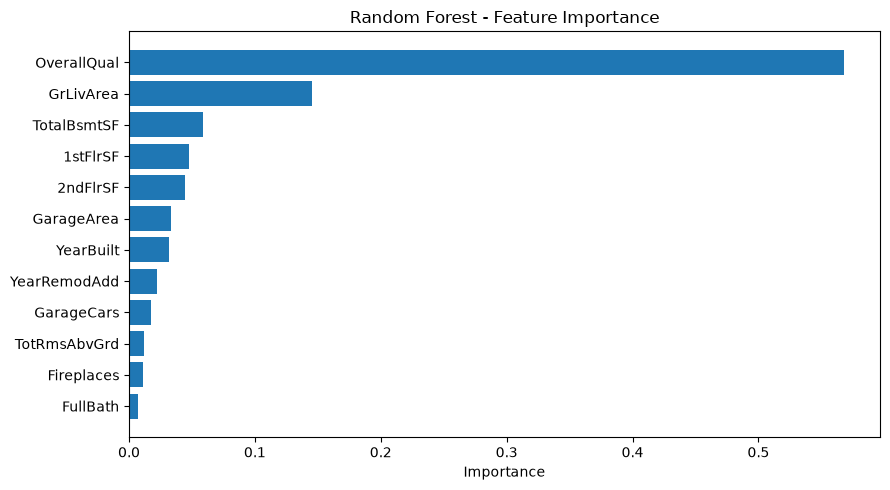

In [7]:
# TODO
# ===== 1·2·3. DataFrame 생성 및 정렬 =====
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(importance)

print(f"중요도 합계   : {importance['importance'].sum():.4f}")
print(f"가장 높은 특성 : {importance.iloc[0]['feature']} ({importance.iloc[0]['importance']:.4f})")
print(f"상위 3개 합계 : {importance.head(3)['importance'].sum():.4f}")

# ===== 4. 막대그래프 =====
plt.figure(figsize=(9, 5))
plt.barh(importance["feature"], importance["importance"])
plt.gca().invert_yaxis()          # 중요한 것이 위로 오게
plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


OverallQual의 막대가 0.23까지 나타나있고, GrLivArea가 0.17이라는 것은  
품질과 지상 면적의 약 40%정도 설명력을 가지고 있다는 것으로 해석할 수 있음  
이 두가지 지표로 전체 중요도의 40%정도이기 때문에 가격변동(Y)의 40%는 중요한 참고 데이터로 사용함  
단  R^2이 40%정도다라고 설명하는 것은 적절하지 않음  

중요도 0.23을 어떻게 해설할 수 있는지?  
가장 정확한 정의는 램덤포레스트의 불순도 기반 중요도에서 OverallQual(품질)이 약 23%정도 차지했다.  

**[잘못된 해석]**  
- 품질이 집값의 23%를 결정한다.
- 품질 1등급을 올리면 가격이 23% 상승한다.  

낮은 중요도는 쓸모없는 변수라는 것을 의미하는가?  
-> 아님, 해당 모델이 예측할 때 조금 덜 힌트를 얻었다는 식으로 설명할 수 있음  

중요도 해석 한계점  
불순도 기반 중요도가 가능한 분할 지점이 많은 특성에 유리하게 작용  
따라서 상관된 특성끼리 중요도가 나뉘거나 쏠리는 현상이 있을 수 있음  

(중요도 점수에 따라서 이 변수들이 어느 정도의 영향이 있었겠거니)   
해석 : 현재 이 모델에서 중요도는 품질 등급과 지상 면적이 가장 크다.  
이 부분은 이 입력구성과 학습설정에서 모델이 예측을 위해 사용한 분할정보의 상대적 기여를 의미한다.  

### Q5. Feature Importance가 높다는 것이 그 변수가 주택가격의 원인이라는 뜻인가요?

**답변:**  
아님. 중요도가 높다라는 것의 올바른 해석은 현재 모델이(설정상태) 예측할 때 많이 활용했다는 의미  


# 과제 1. 나무 수와 예측 안정성 확인

`tree_counts = [1, 10, 50, 100]`을 사용하세요.

각 나무 수에서:
1. RandomForestRegressor 생성
2. `bootstrap=True`, `random_state=42`
3. Train 학습
4. Test R² 계산
5. DataFrame 정리
6. 나무 수에 따른 성능 변화 확인
7. 여러 예측의 평균과 분산 감소 관계 설명

 n_estimators  test_r2
            1 0.742870
           10 0.883597
           50 0.889467
          100 0.890075


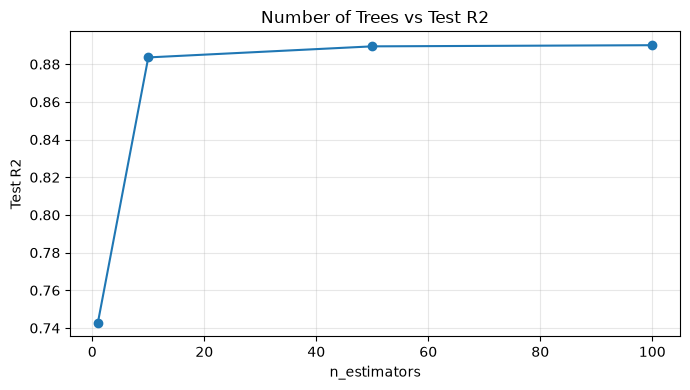

 n_estimators  test_r2  예측_표준편차
            1   0.7429  20488.0
           10   0.8836   6639.1
           50   0.8895   2979.3
          100   0.8901   2152.7


In [8]:
# TODO
tree_counts = [1, 10, 50, 100]
results = []

for k in tree_counts:
    rf = RandomForestRegressor(n_estimators=k, bootstrap=True, random_state=42)   # 1·2
    rf.fit(X_train, y_train)                                                      # 3
    results.append({
        "n_estimators": k,
        "test_r2": r2_score(y_test, rf.predict(X_test)),                          # 4
    })

df = pd.DataFrame(results)                                                        # 5
print(df.to_string(index=False))

# ===== 6. 그래프 =====
plt.figure(figsize=(7, 4))
plt.plot(df["n_estimators"], df["test_r2"], marker="o")
plt.title("Number of Trees vs Test R2")
plt.xlabel("n_estimators"); plt.ylabel("Test R2")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


rows = []
for k in tree_counts:
    rf = RandomForestRegressor(n_estimators=k, bootstrap=True, random_state=42).fit(X_train, y_train)

    # 같은 설정으로 seed 만 바꿔 5번 학습 → 예측이 얼마나 달라지는가
    preds = np.array([
        RandomForestRegressor(n_estimators=k, bootstrap=True, random_state=s)
        .fit(X_train, y_train).predict(X_test)
        for s in range(5)
    ])

    rows.append({
        "n_estimators": k,
        "test_r2": round(r2_score(y_test, rf.predict(X_test)), 4),
        "예측_표준편차": round(preds.std(axis=0).mean(), 1),
    })

print(pd.DataFrame(rows).to_string(index=False))

### Q6. 나무 수를 늘리면 왜 예측이 더 안정적으로 변하나요?

**답변:**  
Random Forest의 예측은 여러 나무의 예측을 평균한 값으로,  
각 나무의 예측이 제각각 다른 방향으로 흔들리면 평균에서 흔들림이 일부 상쇄될 수 있기 때문에 안정적으로 변함.  
-> 평균하는 나무 수가 많아질수록 상쇄되는 정도도 커져 예측 표준편차가 나무 1개일 때 20,488 -> 나무 100개일 때 2,152로 감소함.

### Q7. 나무 수를 계속 늘리면 분산이 무한히 0으로 줄어드나요?

**답변:**  
아니오.  

나무 수를 늘려 평균을 내면 나무마다 다르게 흔들리는 부분은 일부 상쇄되어 줄어들 수 있음.  
하지만 나무들은 같은 Train 데이터로 만들어져 완전히 독립이 아니므로, 공통으로 흔들리는 부분은 평균해도 남음  
(부트스트랩과 특성 무작위 선택으로 줄일 수는 있지만 0이 되지는 않음)  
-> 이 부분이 분산의 하한이 되는 것이며 0으로 줄어들지 않음

# 실습 마무리
1. 부트스트랩 샘플링은 어떤 방식인가요?  
-> 원본 데이터셋이 중복을 허용하여 같은 크기의 샘플을 추출  

2. Bagging 회귀에서는 여러 모델의 예측을 어떻게 합치나요?  
-> 여러 모델의 예측값의 평균  

3. Random Forest가 Bagging에 추가하는 무작위성은 무엇인가요?  
-> 각 트리 분할에서 일부 피처만 무작위 후보로 사용  

4. OOB 샘플은 평균적으로 약 몇 %인가요?  
-> 37%  

5. Feature Importance가 높다는 것은 무엇을 의미하나요?  
-> 모델이 예측에 얼마나 많이 활용했는지  

6. Bagging이 Decision Tree와 특히 잘 맞는 이유는 무엇인가요?  
-> Decision Tree는 기본적으로 분산이 큰 모델인데 배깅의 분산 감소 효과와 잘맞음.  
